In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# the function we want to MINIMISE
def f(x):
    return (x - 3)**2 + 2
# minimum is clearly at x=3, f(3)=2
# we use this to verify our method works

In [3]:
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n-1) + fibonacci(n-2)

# test it
for i in range(10):
    print(fibonacci(i), end=' ')
# output: 0 1 1 2 3 5 8 13 21 34

0 1 1 2 3 5 8 13 21 34 

In [4]:
def fibonacci_search(f, a, b, n):
    """
    f = function to minimise
    a = left bound
    b = right bound  
    n = number of steps (controls accuracy)
    """
    history = []

    for k in range(n, 1, -1):
        Fk  = fibonacci(k)
        Fk1 = fibonacci(k-1)

        x1 = a + (Fk1/Fk) * (b - a)
        x2 = a + b - x1

        history.append((round(a,4), round(b,4)))

        if f(x1) < f(x2):
            b = x2          # discard right portion
        else:
            a = x1          # discard left portion

    minimum = (a + b) / 2
    return minimum, history

Minimum found at x = 10.00000
f(x)             = 51.00000
Iterations       = 9


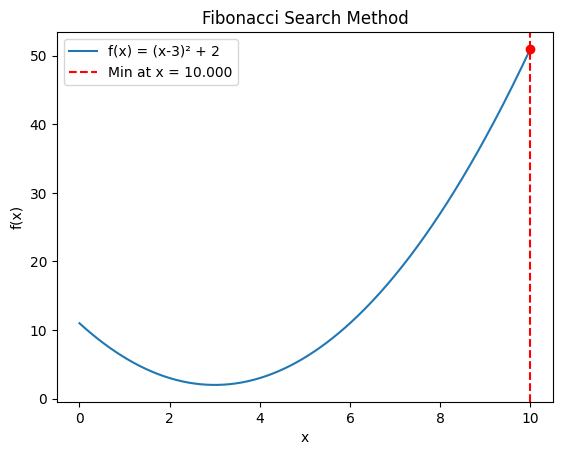


Interval shrinking:
Step 1: [0, 10]  width = 10
Step 2: [6.1818, 10]  width = 3.8182
Step 3: [8.5401, 10]  width = 1.4599
Step 4: [9.4439, 10]  width = 0.5561
Step 5: [9.7861, 10]  width = 0.2139
Step 6: [9.9198, 10]  width = 0.0802
Step 7: [9.9679, 10]  width = 0.0321
Step 8: [9.9893, 10]  width = 0.0107
Step 9: [9.9947, 10]  width = 0.0053


In [5]:
a, b, n = 0, 10, 10      # search between 0 and 10, 10 steps

result, history = fibonacci_search(f, a, b, n)
print(f'Minimum found at x = {result:.5f}')
print(f'f(x)             = {f(result):.5f}')
print(f'Iterations       = {len(history)}')

# Plot the function
x = np.linspace(0, 10, 300)
plt.plot(x, f(x), label='f(x) = (x-3)² + 2')
plt.axvline(result, color='red', linestyle='--',
            label=f'Min at x = {result:.3f}')
plt.scatter([result], [f(result)], color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fibonacci Search Method')
plt.legend()
plt.show()

# Print interval shrinking history
print("\nInterval shrinking:")
for i, (lo, hi) in enumerate(history):
    print(f'Step {i+1}: [{lo}, {hi}]  width = {round(hi-lo, 4)}')